In [ ]:
#|hide
import jax
from jax import numpy as jnp
import matplotlib.pyplot as plt
import pickle
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches

custom_palette = ['#001733', '#13678A', '#60C7BB', '#FFFDA8']
cmap_blue = LinearSegmentedColormap.from_list("custom_cmap", ['#001733', '#13678A', '#60C7BB', '#FFFDA8'])
custom_palette = ['#261B14','#A8774C','#D7B597','#FDF0E9']
cmap_brown2 = LinearSegmentedColormap.from_list("custom_cmap", custom_palette)

This notebook presents how to use QDisc to reproduce the results on the **Falicov-Kimball model** (FKM).

It is one of the simplest lattice models of interacting electrons. We consider the spineless FKM at half filling on a $L\times L$ square lattice, described by the Hamiltonian
$$
    H = -t \sum_{\langle i,j\rangle} \big( d_i^\dagger d_j + d_j^\dagger d_i \big)  + U \sum_i \left( f_i^\dagger f_i - \tfrac{1}{2} \right)\left( d_i^\dagger d_i - \tfrac{1}{2} \right).
$$
Here, $t$ denotes the nearest-neighbor hopping amplitude of the itinerant $d$ fermions and is set to 1. The second term describes a local repulsive interaction of strength $U$ between the localized (heavy) $f$ fermions and the itinerant (light) $d$ fermions occupying the same lattice site. The shifts by $-1/2$ enforce particle-hole symmetry and guarantee half filling.

## dataset and training

The data come from a system size of $N=4\times4$. One part of the data corresponds to the configuration of the localized $f$ particles, with binary entries $0$ and $1$ indicating unoccupied and occupied sites, respectively. Another part corresponds to the local densities of the itinerant $d$ particles and take continuous values in the interval $[0,1]$. We treat the interaction strength $U\in[0,12]$ and the temperature $T\in[0.005,0.3]$ as tuning parameters. The dataset was created from Monte Carlo simulations; further details can be found in https://tinyurl.com/5yt75nwy

In [ ]:
## load the data (not available, this will lead to an error)##

all_U = jnp.array([ 0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,  1.75,  2.  ,
        2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,  4.  ,  4.25,
        4.5 ,  4.75,  5.  ,  5.25,  5.5 ,  5.75,  6.  ,  6.25,  6.5 ,
        6.75,  7.  ,  7.25,  7.5 ,  7.75,  8.  ,  8.25,  8.5 ,  8.75,
        9.  ,  9.25,  9.5 ,  9.75, 10.  , 10.25, 10.5 , 10.75, 11.  ,
       11.25, 11.5 , 11.75, 12.  ])

all_T = jnp.array([0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 , 0.045,
       0.05 , 0.055, 0.06 , 0.065, 0.07 , 0.075, 0.08 , 0.085, 0.09 ,
       0.095, 0.1  , 0.105, 0.11 , 0.115, 0.12 , 0.125, 0.13 , 0.135,
       0.14 , 0.145, 0.15 , 0.155, 0.16 , 0.165, 0.17 , 0.175, 0.18 ,
       0.185, 0.19 , 0.195, 0.2  , 0.205, 0.21 , 0.215, 0.22 , 0.225,
       0.23 , 0.235, 0.24 , 0.245, 0.25 , 0.255, 0.26 , 0.265, 0.27 ,
       0.275, 0.28 , 0.285, 0.29 , 0.295, 0.3  ])

N = 16

with open('cpVAE2_FKM_datasetL4.pkl', 'rb') as f:
    data = pickle.load(f)


In [ ]:
## cast everything in a QDisc Dataset object ##
from qdisc.dataset.core import Dataset

dataset = Dataset(data=data, thetas=[all_T, all_U], data_type='hybrid', local_dimension=2, local_states=jnp.array([0,1]))

In [ ]:
## use Tranformer encoder and decoder ##
from qdisc.nn.core import Transformer_encoder, Transformer_decoder
from qdisc.vae.core import VAEmodel, VAETrainer

encoder = Transformer_encoder(latent_dim=5, d_model=16, num_heads=2, num_layers=3, data_type='hybrid')
decoder = Transformer_decoder(d_model=32, num_heads=4, num_layers=3, data_type='hybrid')

myvae = VAEmodel(encoder=encoder, decoder=decoder)
myvaetrainer = VAETrainer(model=myvae, dataset=dataset)

Start training...
epoch=0 step=0 loss=14.992286682128906 recon=12.066333770751953
logvar=[ 0.17164478 -0.7916552   0.59649426 -0.20737162  0.22081801]
epoch=5 step=0 loss=-4.412041664123535 recon=-4.728668689727783
logvar=[-0.02302684 -1.411141   -0.01582469 -0.01229799 -0.13648185]
epoch=10 step=0 loss=-5.042297840118408 recon=-5.741966724395752
logvar=[-1.4142735e-02 -3.0865104e+00 -1.4765011e-02 -1.6659213e-02
 -2.2206940e-03]
epoch=15 step=0 loss=-5.661174774169922 recon=-6.669913291931152
logvar=[-3.0383343e-01 -4.1715732e+00 -1.5086111e-02  2.0773024e-03
 -7.9769846e-03]
epoch=20 step=0 loss=-4.9785661697387695 recon=-6.233368873596191
logvar=[-9.5500028e-01 -4.6541462e+00 -8.8674333e-03 -3.8200682e-03
 -8.4259398e-03]
epoch=25 step=0 loss=-6.249385356903076 recon=-7.600369930267334
logvar=[-1.2291127e+00 -4.7380981e+00 -1.2818130e-02 -1.0840525e-03
 -9.3268533e-04]
epoch=30 step=0 loss=-6.303691387176514 recon=-7.699682235717773
logvar=[-1.3750013e+00 -4.8349504e+00 -6.5440750e-

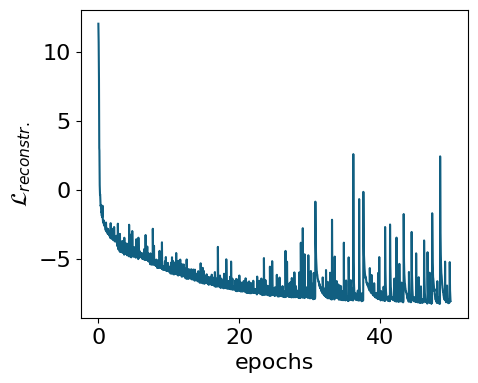

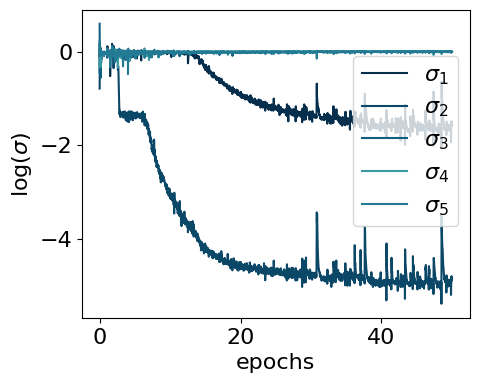

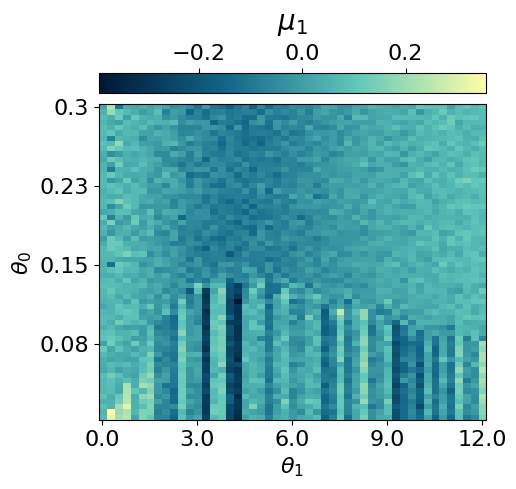

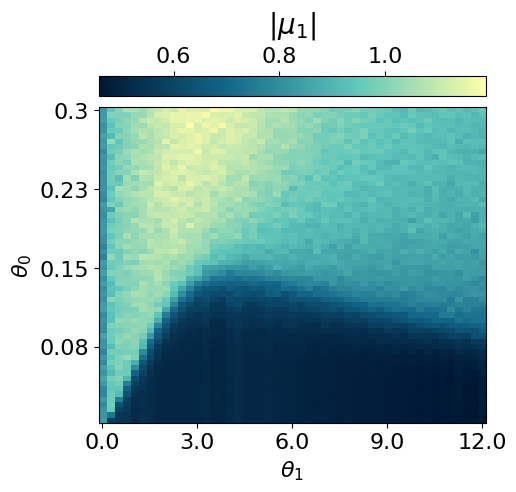

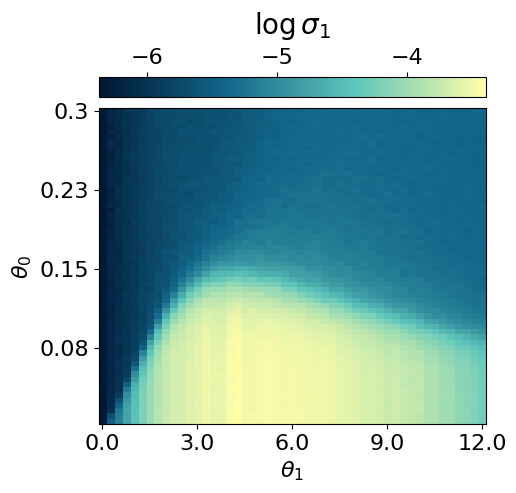

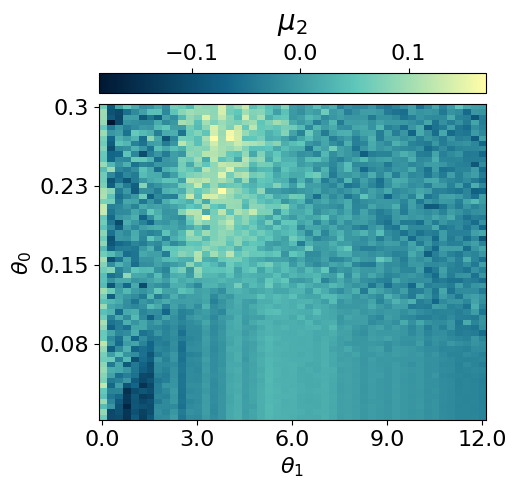

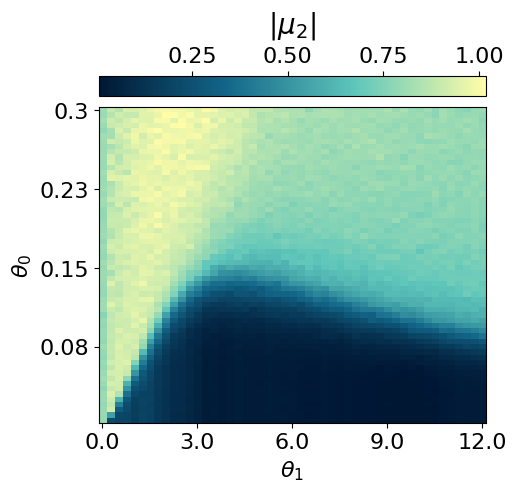

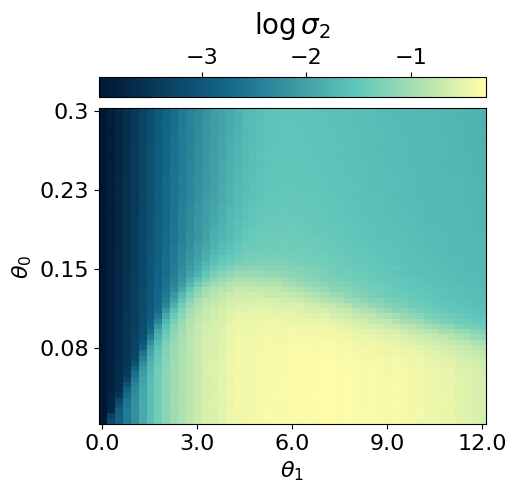

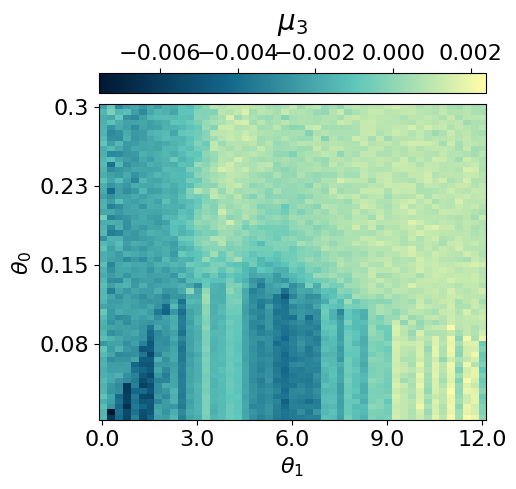

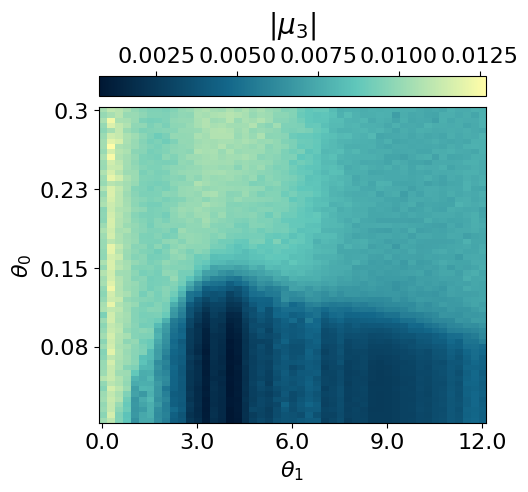

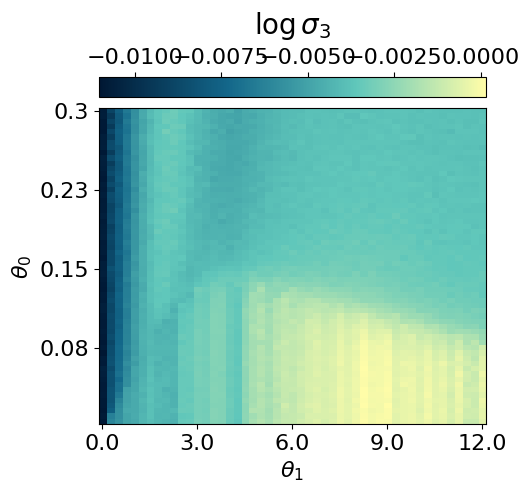

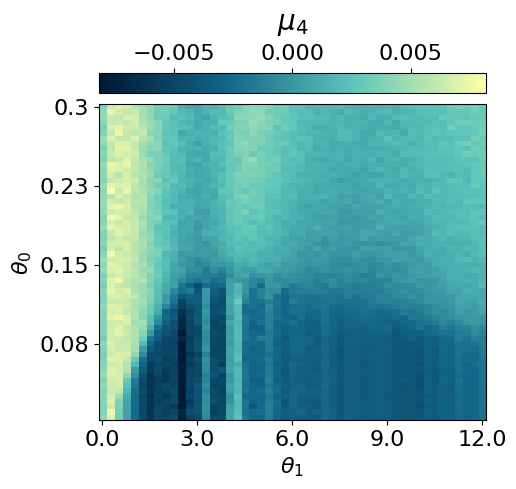

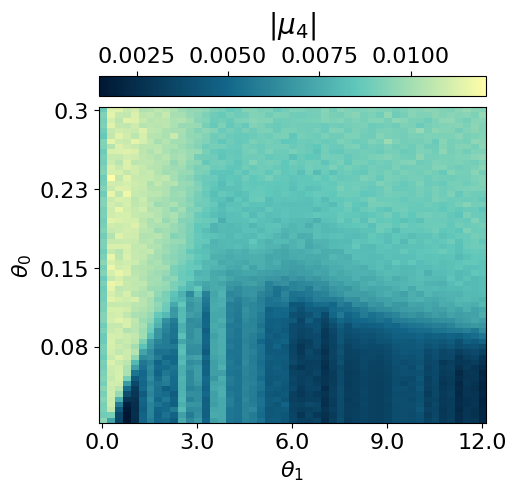

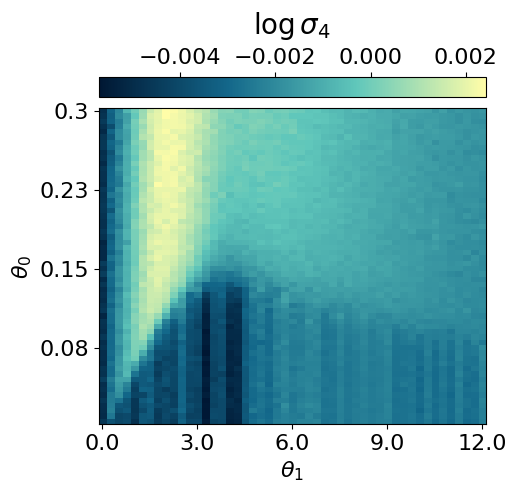

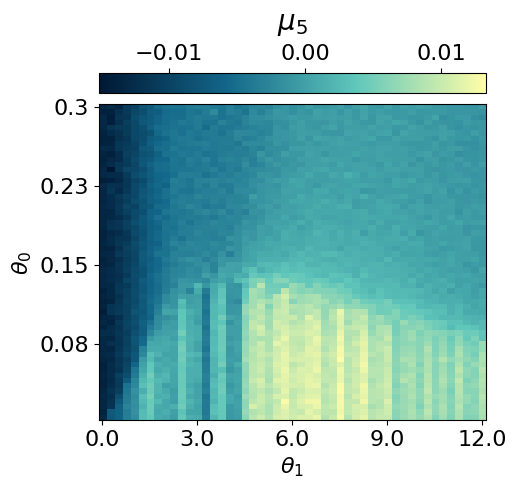

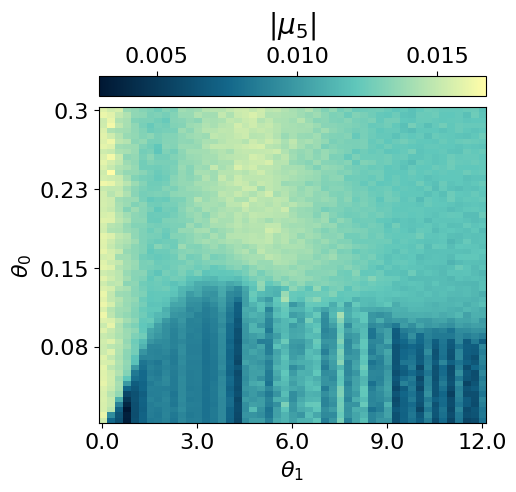

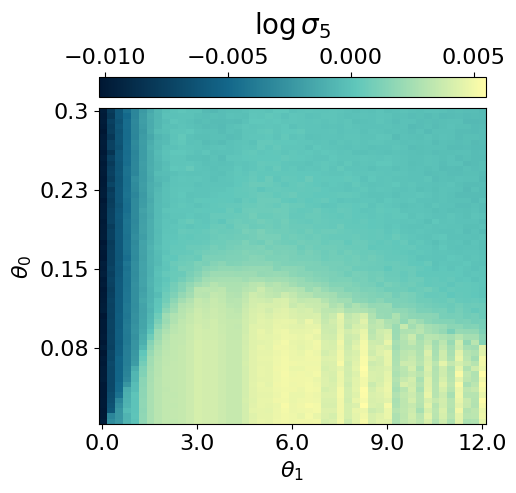

In [ ]:
## Training ##
num_epochs = 50
alpha = 0.8
beta = 0.45
lr = 0.0001

myvaetrainer = VAETrainer(model=myvae, dataset=dataset)
key = jax.random.PRNGKey(6750)
myvaetrainer.train(num_epochs=num_epochs,
                  batch_size=10000,
                  beta=beta,
                  alpha=alpha,
                  gamma=0.,
                  key=key,
                  printing_rate=5,
                  learning_rate = lr,
                  re_shuffle=False)
myvaetrainer.plot_training(num_epochs=num_epochs)
myvaetrainer.compute_and_plot_repr2d(theta_pair=(0,1))

In [ ]:
## saving the data ##
all_data = myvaetrainer.get_data()

with open('FKM_data_cpVAE2_QDisc2.pkl', 'wb') as f:
    pickle.dump(all_data, f)

## Looking at the conditional probabilities

As in the Radberg case, we can examine the conditional probabilities output by the decoder to understand the ordering at different locations in the parameter space.

In [ ]:
with open('FKM_data_cpVAE2_QDisc2.pkl', 'rb') as f:
   all_data = pickle.load(f)

In [ ]:
state = train_state.TrainState.create(
            apply_fn=myvaetrainer.model.apply,
            params=all_data['params'],
            tx=myvaetrainer.opt
        )

myvaetrainer.state = state

### OP

The ordered phase (OP) is characterised by a checkerboard pattern of f and d particles. There is also interspecies repulsion induced by U, which can be visualised by examining the conditional probabilities within the OP at low and high U values.

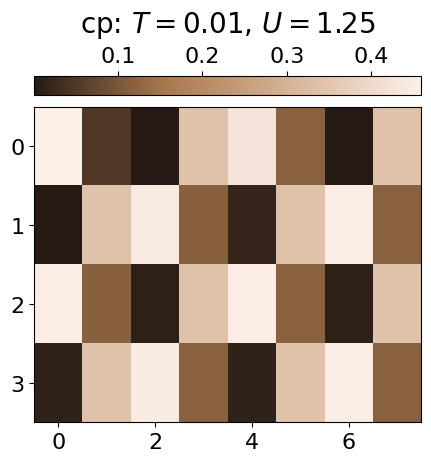

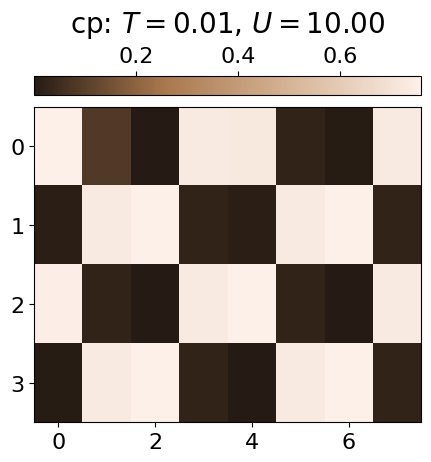

In [ ]:
locations = [(2,5), (2,40)]
key = jax.random.PRNGKey(6795)
all_cp = []


for i,j in locations:
  f_out, d_out = myvaetrainer.get_cp(dataset.data[i,j])
  p_f = jnp.exp(f_out)[...,1]
  p_d = d_out[...,0]
  cp = jnp.zeros((jnp.shape(dataset.data)[2],2*N))
  cp = cp.at[:,0::2].set(p_f)
  cp = cp.at[:,1::2].set(p_d)
  all_cp.append(cp)


  plt.rcParams['font.size'] = 16
  plt.figure(figsize=(5,5),dpi=100)

  plt.imshow(jnp.mean(cp*dataset.data[i,j][:,0][:,None],axis=0).reshape(4,8), cmap=cmap_brown2, aspect='auto')#,vmin=0.3)

  cbar = plt.colorbar(orientation="horizontal", pad=0.03, location="top")
  cbar.set_label(r'cp: $T={0:.2f}$, $U={1:.2f}$'.format(all_T[i], all_U[j]), fontsize=20, labelpad=10)


all_data['all_cp'] = all_cp


### Repulsion

The repulsion between the species can also be visualised throughout the entire parameter space by calculating the average probability of a site being occupied by both an f and a d particle.

In [ ]:
key = jax.random.PRNGKey(6845)

cp_fd = jnp.zeros((dataset.data.shape[0],dataset.data.shape[1]))


for i in range(len(all_T)):
    for j in range(len(all_U)):
      f_out, d_out = myvaetrainer.get_cp(dataset.data[i,j])
      p_f = jnp.exp(f_out)[...,1]
      p_d = d_out[...,0]
      cp = jnp.zeros((jnp.shape(dataset.data)[2],2*N))
      cp = cp.at[:,0::2].set(p_f)
      cp = cp.at[:,1::2].set(p_d)

      cp_fd = cp_fd.at[i,j].set(jnp.mean(p_f*p_d))



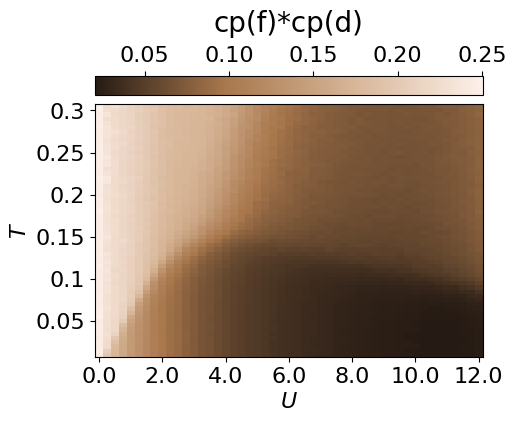

In [ ]:
plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=100)

plt.imshow(jnp.flipud(cp_fd), cmap=cmap_brown2, aspect='auto')#,vmin=0.,vmax=0.8)

cbar = plt.colorbar(orientation="horizontal", pad=0.03, location="top")
cbar.set_label(r'cp(f)*cp(d)', fontsize=20, labelpad=10)



plt.xlabel(r'$U$')
plt.ylabel(r'$T$')
plt.xticks([i for i in range(0,len(all_U)+1,8)], [str(all_U[i]) for i in range(0,len(all_U)+1,8)])
plt.yticks([i for i in range(1,len(all_T),10)], [str(all_T[len(all_T)-i]) for i in range(1,len(all_T),10)])
''
plt.show()

In [ ]:
all_data['cp_fd'] = cp_fd

### IPR

From the conditional probabilities, one can also compute an inverse participation ratio (IPR). This measures the degree of localisation of f/d particles and highlights the weak localisation region.

In [ ]:
key = jax.random.PRNGKey(6795)
all_cp = []


IPR_d = jnp.zeros((dataset.data.shape[0],dataset.data.shape[1]))
IPR_f = jnp.zeros((dataset.data.shape[0],dataset.data.shape[1]))
IPR_fd = jnp.zeros((dataset.data.shape[0],dataset.data.shape[1]))

for i in range(len(all_T)):
    for j in range(len(all_U)):
      f_out, d_out = myvaetrainer.get_cp(dataset.data[i,j])
      p_f = jnp.exp(f_out)[...,1]
      p_d = d_out[...,0]
      cp = jnp.zeros((jnp.shape(dataset.data)[2],2*N))
      cp = cp.at[:,0::2].set(p_f)
      cp = cp.at[:,1::2].set(p_d)
      all_cp.append(cp)


      IPR_d = IPR_d.at[i,j].set(jnp.mean(p_d**2))
      IPR_f = IPR_f.at[i,j].set(jnp.mean(p_f**2))
      IPR_fd = IPR_fd.at[i,j].set(jnp.mean(p_f**2*p_d**2))



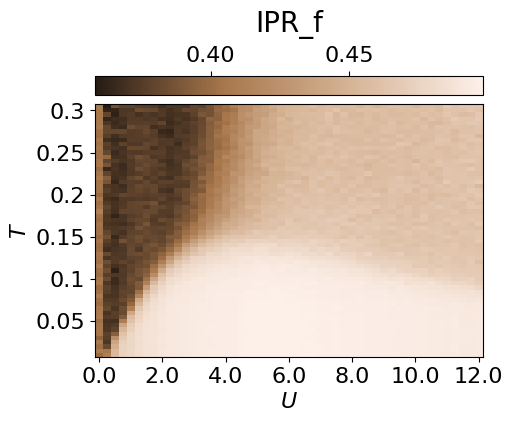

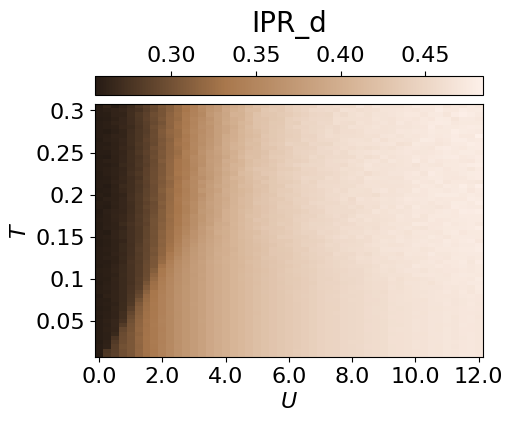

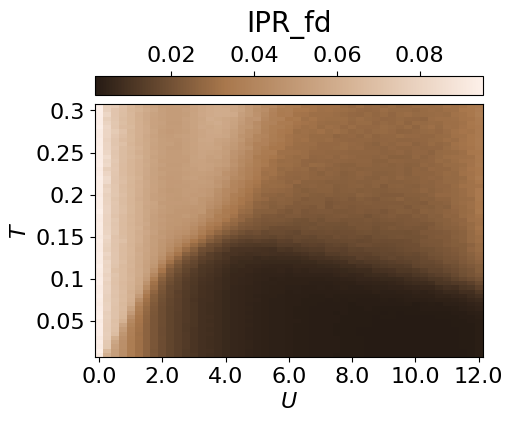

In [ ]:
plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=100)

plt.imshow(jnp.flipud(IPR_f), cmap=cmap_brown2, aspect='auto')#,vmin=0.,vmax=0.8)

cbar = plt.colorbar(orientation="horizontal", pad=0.03, location="top")
cbar.set_label(r'IPR_f', fontsize=20, labelpad=10)



plt.xlabel(r'$U$')
plt.ylabel(r'$T$')
plt.xticks([i for i in range(0,len(all_U)+1,8)], [str(all_U[i]) for i in range(0,len(all_U)+1,8)])
plt.yticks([i for i in range(1,len(all_T),10)], [str(all_T[len(all_T)-i]) for i in range(1,len(all_T),10)])

plt.show()


plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=100)

plt.imshow(jnp.flipud(IPR_d), cmap=cmap_brown2, aspect='auto')#,vmin=0.,vmax=0.8)

cbar = plt.colorbar(orientation="horizontal", pad=0.03, location="top")
cbar.set_label(r'IPR_d', fontsize=20, labelpad=10)



plt.xlabel(r'$U$')
plt.ylabel(r'$T$')
plt.xticks([i for i in range(0,len(all_U)+1,8)], [str(all_U[i]) for i in range(0,len(all_U)+1,8)])
plt.yticks([i for i in range(1,len(all_T),10)], [str(all_T[len(all_T)-i]) for i in range(1,len(all_T),10)])

plt.show()


plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=100)

plt.imshow(jnp.flipud(IPR_fd), cmap=cmap_brown2, aspect='auto')#,vmin=0.,vmax=0.8)

cbar = plt.colorbar(orientation="horizontal", pad=0.03, location="top")
cbar.set_label(r'IPR_fd', fontsize=20, labelpad=10)



plt.xlabel(r'$U$')
plt.ylabel(r'$T$')
plt.xticks([i for i in range(0,len(all_U)+1,8)], [str(all_U[i]) for i in range(0,len(all_U)+1,8)])
plt.yticks([i for i in range(1,len(all_T),10)], [str(all_T[len(all_T)-i]) for i in range(1,len(all_T),10)])

plt.show()


In [ ]:
all_data['IPR'] = IPR_f

In [ ]:
with open('FKM_data_cpVAE2_QDisc2.pkl', 'wb') as f:
    pickle.dump(all_data, f)

## Clustering the latent representation

In this case, it is not completely obvious how to **map the latent representation onto a discrete phase-space diagram**. Therefore, we use the Gaussian Mixture Model implemented in `QDisc.Clustering`. More details are presented in the tutorail on the J1J2 model.

GMM with n_components: 6


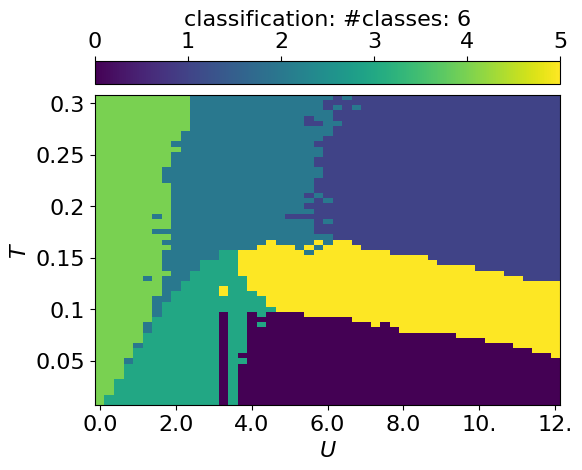

In [ ]:
from qdisc.clustering.core import GaussianMixture

#get the latent representation

latvar = all_data['latvar']
mu0abs = latvar['mu0_abs']
mu1abs = latvar['mu1_abs']
theta_pair = (0,1)

#get the experimental parameters thetas to weight on the parameter space distance by alpha and have a smooter clustering
alpha = 0.5
theta1 = dataset.thetas[theta_pair[0]]
theta2 = dataset.thetas[theta_pair[1]]
theta1_norm = (theta1 - jnp.min(theta1)) / (jnp.max(theta1) - jnp.min(theta1))
theta2_norm = (theta2 - jnp.min(theta2)) / (jnp.max(theta2) - jnp.min(theta2))

#vector to perform the GMM one
X = jnp.array([mu0abs.reshape(-1),
               mu1abs.reshape(-1),
               alpha*jnp.tile(theta1_norm[:,None], reps=(jnp.size(theta2_norm),)).reshape(-1),
               alpha*jnp.tile(theta2_norm[None, :], reps=(jnp.size(theta1_norm),)).reshape(-1)]).transpose()


for n_components in [6]:

    print('GMM with n_components: {}'.format(n_components))

    clusterer = GaussianMixture(
                                n_components=n_components,
                                max_iter=500,
                                init_params="kmeans"
                            )

    clusterer.fit(X, key=jax.random.PRNGKey(4362))



    classes = clusterer.predict(X).reshape((jnp.size(theta1),jnp.size(theta2)))

    final_classes = jnp.zeros((jnp.size(theta1),jnp.size(theta2)))
    for i in range(jnp.size(theta1)):
      for j in range(jnp.size(theta2)):
        v, c = jnp.unique_counts(classes[i,j])
        final_classes = final_classes.at[i,j].set(v[jnp.argmax(c)])


    fig_shape = (len(theta1)/10, len(theta2)/10)

    plt.rcParams['font.size'] = 16
    plt.figure(figsize=fig_shape,dpi=100)


    plt.imshow(jnp.flipud(final_classes), aspect='auto')
    cbar = plt.colorbar(orientation="horizontal", pad=0.03, location="top")
    cbar.set_label(r'classification: #classes: {}'.format(n_components))

    plt.xlabel(r'$U$')
    plt.ylabel(r'$T$')
    plt.xticks([i for i in range(0,len(all_U)+1,8)], [str(all_U[i])[:3] for i in range(0,len(all_U)+1,8)])
    plt.yticks([i for i in range(1,len(all_T),10)], [str(all_T[len(all_T)-i]) for i in range(1,len(all_T),10)])


    plt.show()

## Symbolic regression

In this section, we employ `QDisc.SR.SymbolicRegression` to investigate the **nature of the additional cluster** observed in the latent representation. We will use the `'2_body_correlator'` ansatz with the **SR1** objective.

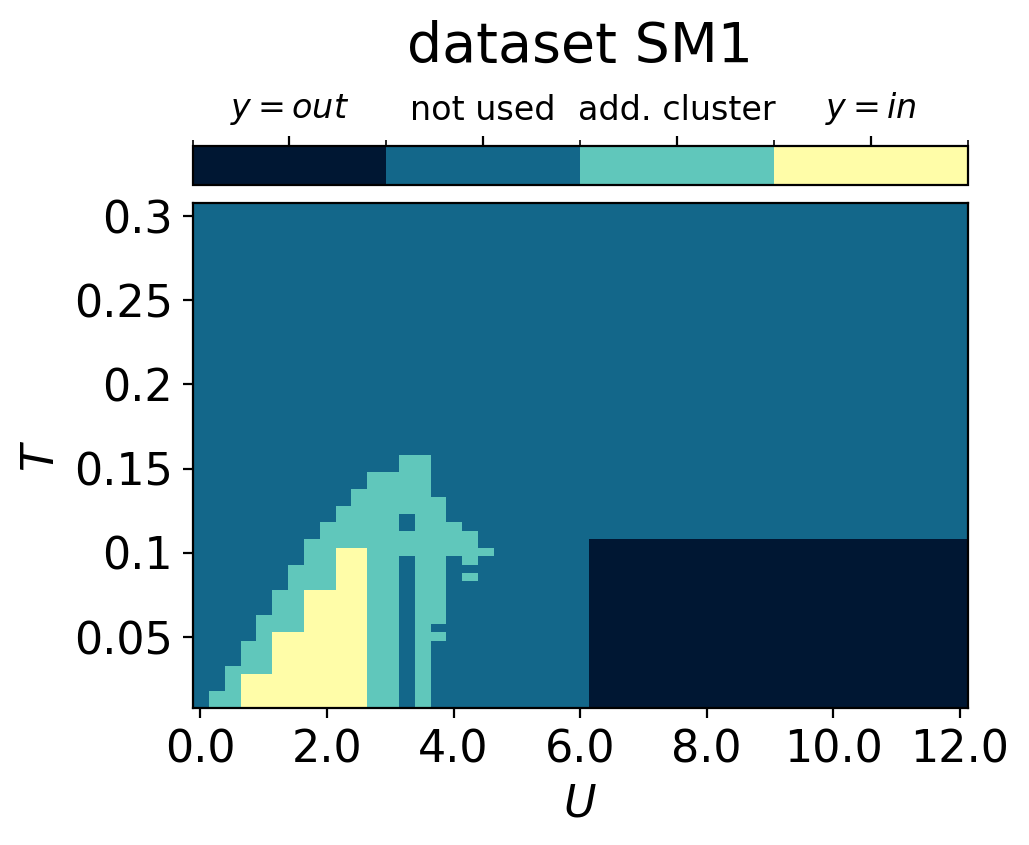

In [ ]:
## set the index of the in/out classes for SR1 ##

import matplotlib.colors as mcolors
id_add_cluster = jnp.argwhere(classes == 3)

array_inisde_add_cluster = jnp.zeros((len(all_T),len(all_U)))
array_inisde_add_cluster = array_inisde_add_cluster.at[:14,7:11].add(1)
array_inisde_add_cluster = array_inisde_add_cluster.at[:19,9:11].set(1)
array_inisde_add_cluster = array_inisde_add_cluster.at[:4,3:11].set(1)
array_inisde_add_cluster = array_inisde_add_cluster.at[:9,5:11].set(1)

id_in_add_cluster = jnp.argwhere(array_inisde_add_cluster == 1)


array_outside_add_cluster = jnp.zeros((len(all_T),len(all_U)))
array_outside_add_cluster = array_outside_add_cluster.at[:20,25:].set(1)


id_out_add_cluster = jnp.argwhere(array_outside_add_cluster == 1)


array_add_cluster = jnp.ones((len(all_T),len(all_U)))

for i,j in id_add_cluster:
  array_add_cluster = array_add_cluster.at[i,j].set(2)

for i,j in id_in_add_cluster:
  array_add_cluster = array_add_cluster.at[i,j].set(3)

for i,j in id_out_add_cluster:
  array_add_cluster = array_add_cluster.at[i,j].set(0)


plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=200)

n_bins = 4
bounds = jnp.linspace(0, 4, n_bins + 1)
mid_points = (bounds[:-1] + bounds[1:]) / 2
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=cmap_blue.N, clip=True)

plt.imshow(jnp.flipud(array_add_cluster),cmap=cmap_blue, aspect='auto', norm=norm)
cbar = plt.colorbar(orientation="horizontal", pad=0.03, location="top", ticks=mid_points)
cbar.set_label(r'dataset SM1', fontsize=20, labelpad=10)
cbar.set_ticklabels([r'$y=out$', r'not used', r'add. cluster',r'$y=in$'], fontsize=12)


plt.xlabel(r'$U$')
plt.ylabel(r'$T$')
plt.xticks([i for i in range(0,len(all_U)+1,8)], [str(all_U[i]) for i in range(0,len(all_U)+1,8)])
plt.yticks([i for i in range(1,len(all_T),10)], [str(all_T[len(all_T)-i]) for i in range(1,len(all_T),10)])
plt.show()

### Start preparing the dataset ###
### Dataset prepared, start the trainnig ###
### Training finished ###
  message: STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT
  success: False
   status: 1
      fun: 0.2666763252831029
        x: [-3.365e-02  2.370e-01 ...  1.979e-03  4.940e-01]
      nit: 28
      jac: [-3.676e-03  3.167e-03 ... -1.641e-04 -7.234e-05]
     nfev: 15438
     njev: 31
 hess_inv: <497x497 LbfgsInvHessProduct with dtype=float64>


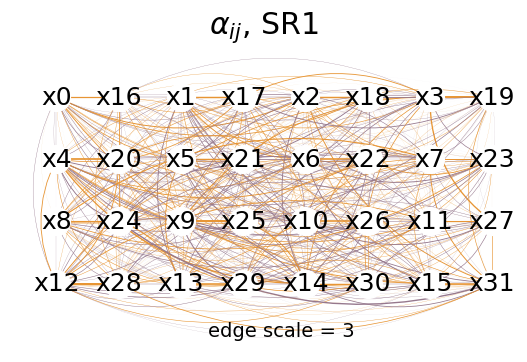

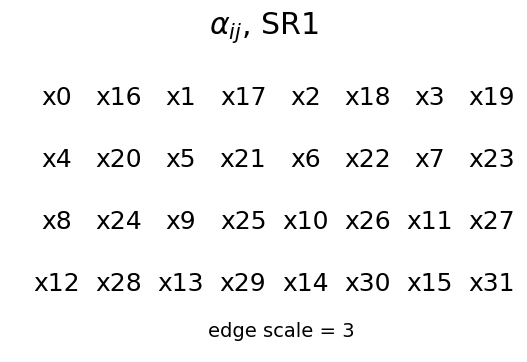

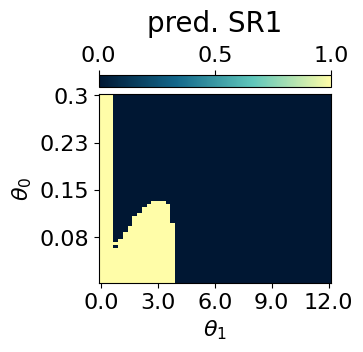

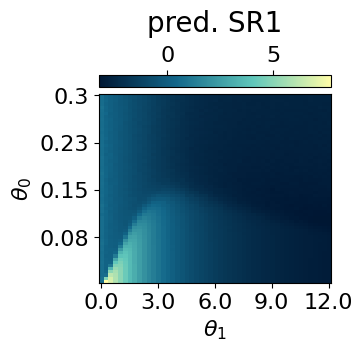

In [ ]:
## 2BC with SR1 ##

from qdisc.sr.core import SymbolicRegression

cluster_idx_in = id_in_add_cluster
cluster_idx_out = id_out_add_cluster


f = jnp.arange(0,N,1)
d = jnp.arange(N,2*N,1)
fd = jnp.zeros((2*N,))
fd = fd.at[::2].set(f)
fd = fd.at[1::2].set(d).astype(jnp.int32)
fd = fd.reshape(4,8).tolist()
topology = fd

key = jax.random.PRNGKey(1011)

l1 = 2
mySR = SymbolicRegression(dataset,
                          cluster_idx_in=cluster_idx_in,
                          cluster_idx_out=cluster_idx_out,
                          objective='SR1',
                          shift_data=True,
                          add_constant=True)


_ = mySR.train_2BC(key, dataset_size=10000, L1_reg=l1, max_iter=1000)


mySR.plot_alpha(topology=topology, edge_scale=3, name='SR1', threshold=0.)
mySR.plot_alpha(topology=topology, edge_scale=3, name='SR1', threshold=1.)

## plot the classification prediction f(x)>0 ##
p = mySR.compute_and_plot_prediction(name='SR1', class_pred=True, theta_pair=(0,1))
p = mySR.compute_and_plot_prediction(name='SR1', class_pred=False, theta_pair=(0,1))

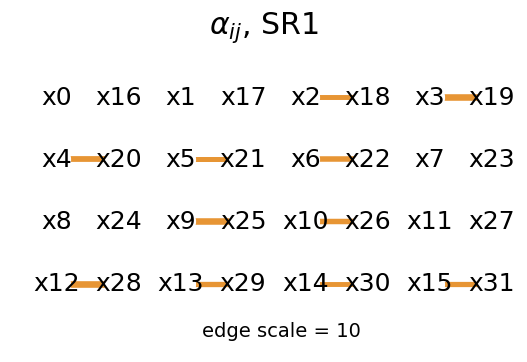

In [ ]:
mySR.plot_alpha(topology=topology, edge_scale=10, name='SR1', threshold=0.35)